In [3]:
import sys 
sys.path.append("..") 
import numpy as np
from SWMM import SWMM_ENV
import HC
import datetime
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from swmm_api import read_out_file
import os

In [4]:
raindatae = np.load(os.path.dirname(os.getcwd())+'\\rainfall\\training_raindata.npy').tolist()

In [8]:
env_params={
    'orf':os.path.dirname(os.getcwd())+'\\SWMM\\chaohu',
    'orf_save':'chaohu_RTC',
    'parm':os.path.dirname(os.getcwd())+'\\states_yaml\\chaohu',
    'advance_seconds':300,
    'kf':1,
    'kc':1,
    'reward_type':'1'
}
env=SWMM_ENV.SWMM_ENV(env_params)

In [9]:
def HC_interact(i): 
    observation, episode_return, episode_length = env.reset(raindatae[i],i,False,os.path.dirname(os.getcwd())), 0, 0
    storage_states = {'CC-storage':observation[0],'JK-storage':observation[1]}
    done, t= False, 0
    at = [0 for _ in range(7)]
    foreaction=[0 for _ in range(7)]
    while not done:
        observation = np.array(observation).reshape(1, -1)
        if np.mod(t,10)==0:
            at = HC.HC_sample_action(foreaction,storage_states)
            foreaction = at
        observation_new,reward,results,done = env.step(at)
        storage_states = {'CC-storage':observation_new[0],'JK-storage':observation_new[1]}
        t += 1
        observation = observation_new
    return env.results

In [10]:
results = HC_interact(0)

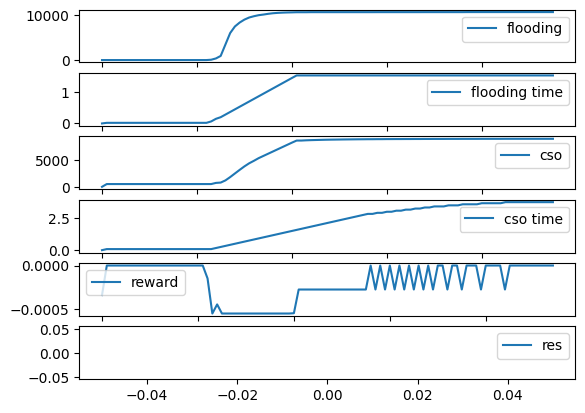

In [11]:
fig,ax = plt.subplots(6,1)
ax[0].plot(results['flooding'],label='flooding')
ax[0].legend()
ax[1].plot(results['total_flooding_time'],label='flooding time')
ax[1].legend()
ax[2].plot(results['CSO'],label='cso')
ax[2].legend()
ax[3].plot(results['total_CSO_time'],label='cso time')
ax[3].legend()
ax[4].plot(results['rewards'],label = 'reward')
ax[4].legend()
ax[5].plot(results['res'],label='res')
ax[5].legend()